<a href="https://colab.research.google.com/github/AFK-Kuntal/MNIST-DigitClassification/blob/main/Digit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
tf.__version__

'2.20.0'

In [4]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# **Importing Dataset and Preprocessing**

In [5]:
def load_data_and_preprocess():
  (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
  X_train = X_train.astype('float32') / 255.0
  X_test = X_test.astype('float32') / 255.0
  X_train = np.expand_dims(X_train, -1)
  X_test = np.expand_dims(X_test, -1)
  return (X_train, y_train), (X_test, y_test)

In [6]:
(X_train, y_train), (X_test, y_test) = load_data_and_preprocess()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
print(type(X_train))
X_train

<class 'numpy.ndarray'>


array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = SEED)

In [9]:
print(f"the shape of the train set is {X_train.shape}")
print(f"the shape of the val set is {X_val.shape}")
print(f"the shape of the test set is {X_test.shape}")

the shape of the train set is (48000, 28, 28, 1)
the shape of the val set is (12000, 28, 28, 1)
the shape of the test set is (10000, 28, 28, 1)


In [10]:
def plot_digits(X, y):
  for i in range(20):
    idx = np.random.randint(0, len(X))
    plt.subplot(4, 5, i + 1)
    plt.imshow(X[idx].squeeze(), cmap = 'gray')
    plt.title(f"Digit: {y[i]}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

# **Exploratory Data Analysis(EDA)**

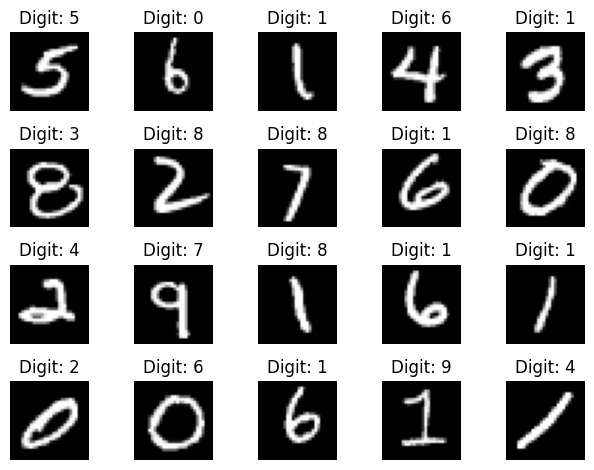

In [11]:
plot_digits(X_train, y_train)

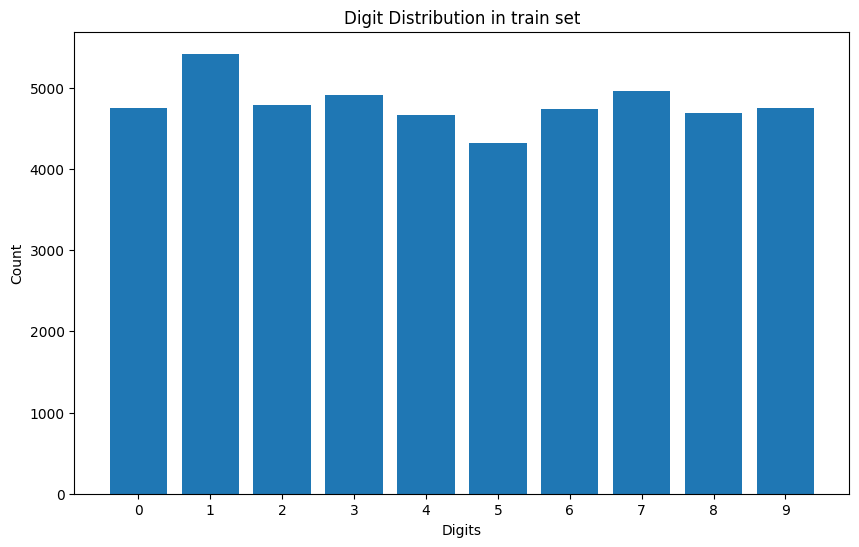

In [12]:
unique_labels, counts = np.unique(y_train, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels, counts)
plt.xticks(unique_labels)
plt.xlabel("Digits")
plt.ylabel("Count")
plt.title("Digit Distribution in train set")
plt.show()

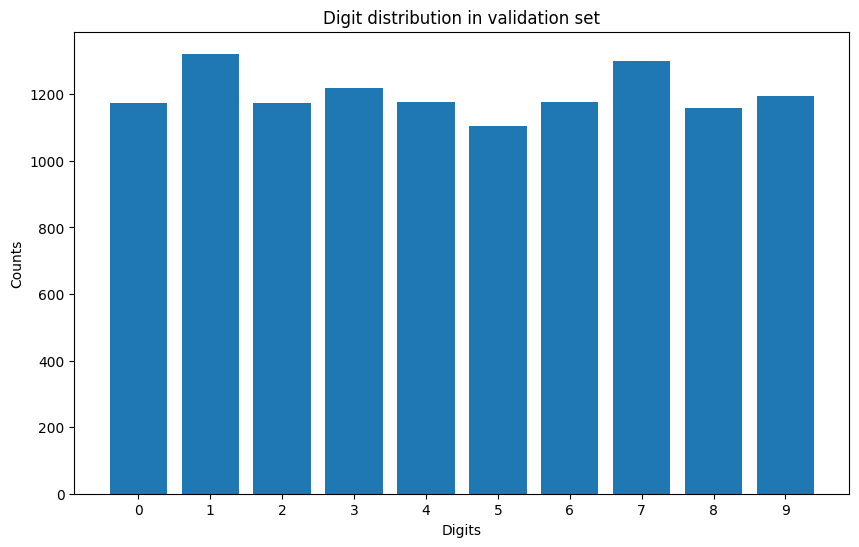

In [13]:
unique_labels_val, counts_val = np.unique(y_val, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels_val, counts_val)
plt.xticks(unique_labels_val)
plt.xlabel("Digits")
plt.ylabel("Counts")
plt.title("Digit distribution in validation set")
plt.show()

In [14]:
from keras import Sequential
from keras.layers import *

# **CNN Architecture and Training**

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [15]:
InputSize = X_train[0].shape
Batch = 32
Epochs = 15

In [16]:
model = Sequential([
    layers.Input(shape = InputSize),

    layers.Conv2D(32, (3,3), 1, padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), 1, activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, 3, 1, activation = 'relu'),
    layers.MaxPooling2D(2),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(len(unique_labels), 'softmax')
])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,138 (656.79 KB)

 Trainable params: 167,690 (655.04 KB)

 Non-trainable params: 448 (1.75 KB)

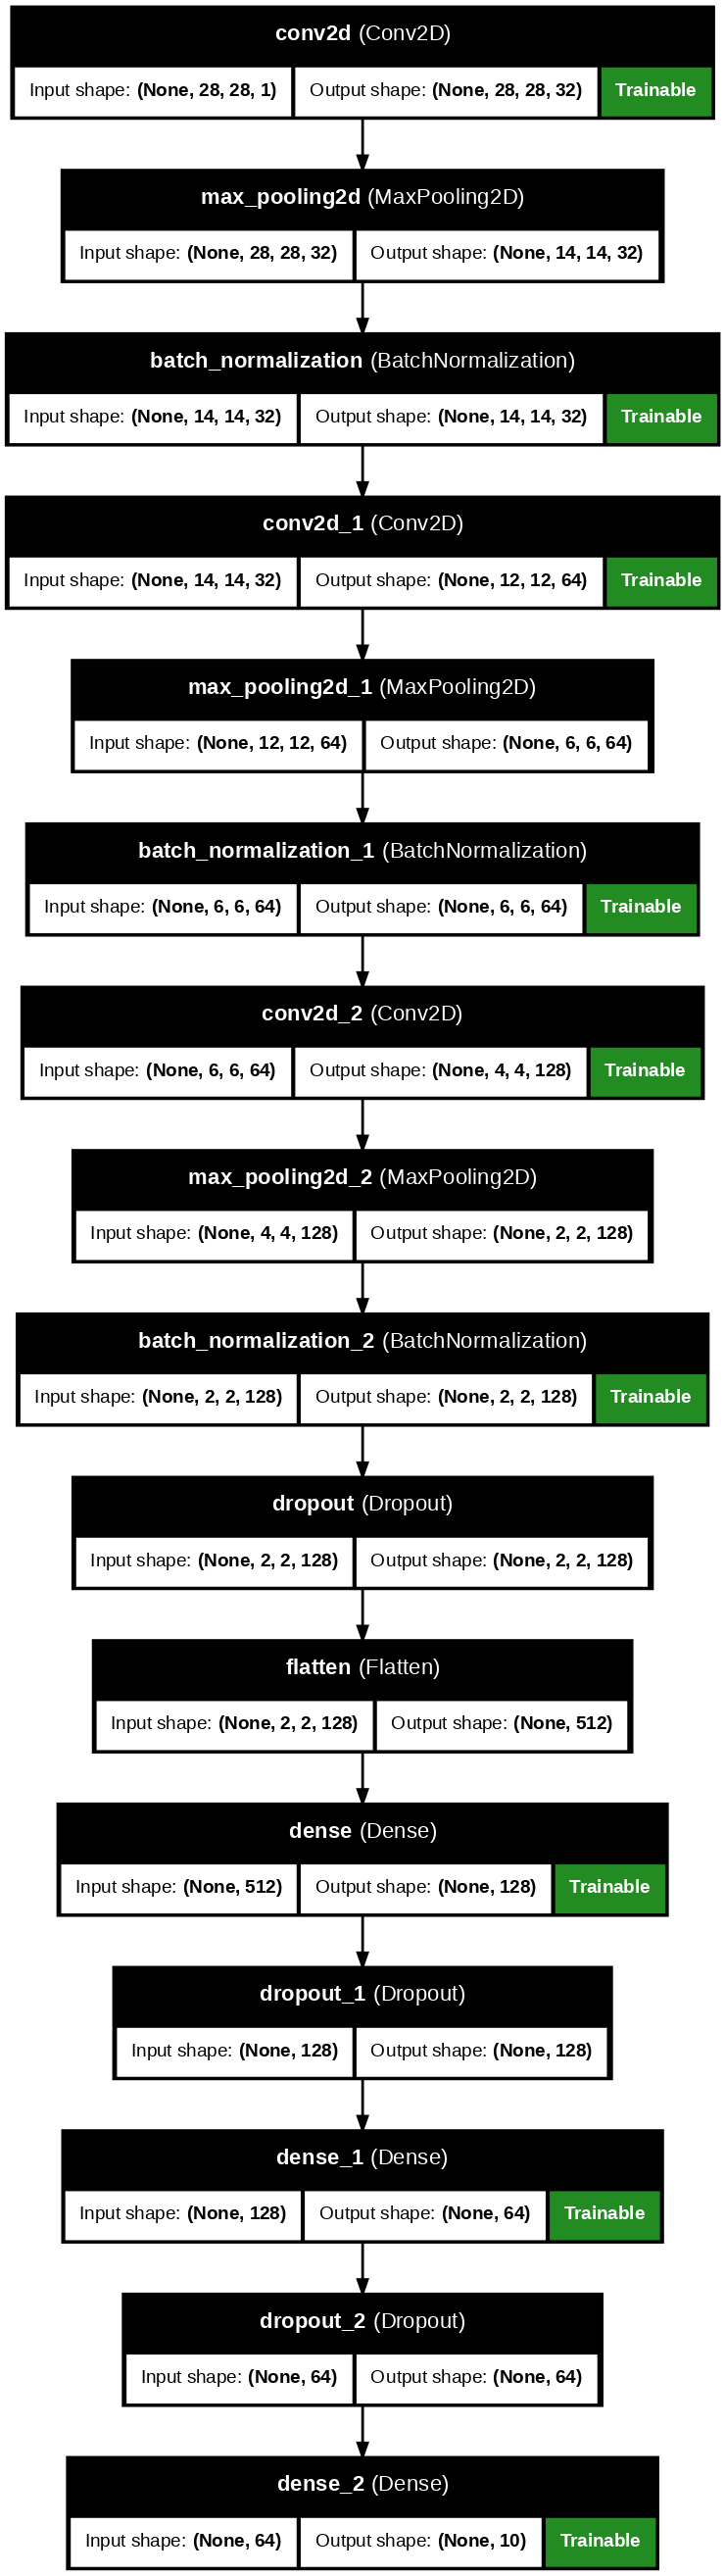

In [18]:
from tensorflow.keras.utils import plot_model
plot_model(model, dpi = 100, show_shapes = True, show_layer_names = True, show_trainable = True)

In [19]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [20]:
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True),
    keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', patience = 3, min_lr = 1e-6)
]

In [21]:
history = model.fit(
    X_train, y_train, #datagen.flow(X_train, y_train, batch_size = Batch)
    batch_size = Batch,
    epochs = Epochs,
    validation_data = (X_val, y_val),
    callbacks = my_callbacks
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9092 - loss: 0.2943 - val_accuracy: 0.9852 - val_loss: 0.0486 - learning_rate: 0.0010
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9725 - loss: 0.1013 - val_accuracy: 0.9837 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9783 - loss: 0.0785 - val_accuracy: 0.9861 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9820 - loss: 0.0670 - val_accuracy: 0.9883 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9840 - loss: 0.0575 - val_accuracy: 0.9906 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0507 - val_accuracy: 0.9899 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9870 -

# **Evaluating Training Performance**

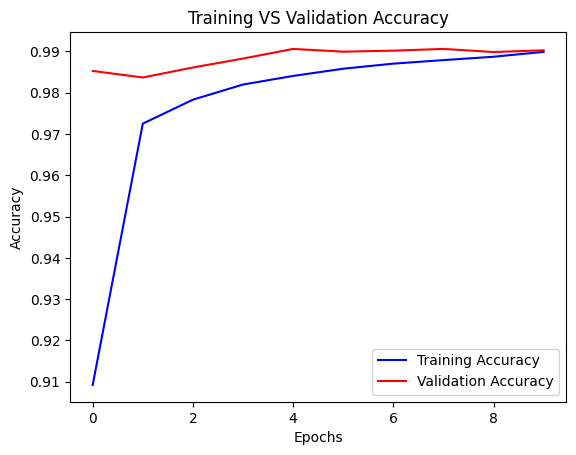

In [22]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy', color = 'blue')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy', color = 'red')
plt.title("Training VS Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

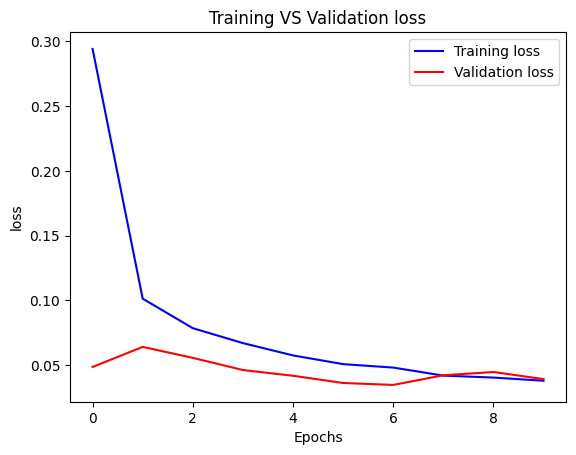

In [23]:
plt.plot(history.history['loss'], label = 'Training loss', color = 'blue')
plt.plot(history.history['val_loss'], label = 'Validation loss', color = 'red')
plt.title("Training VS Validation loss")
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

# **Model Evaluation**

In [24]:
test_results = model.evaluate(X_test, y_test)
print(f"Test Accuracies: {test_results[1] * 100:.2f}")
print(f"Train Accuracies: {test_results[0] * 100 : .2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9920 - loss: 0.0249
Test Accuracies: 99.20
Train Accuracies:  2.49


In [25]:
Validation_results = model.evaluate(X_val, y_val)
print(f"Validation Accuracies: {Validation_results[1] * 100:.2f}")
print(f"Validation Loss: {Validation_results[0] * 100:.2f}")

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9902 - loss: 0.0347
Validation Accuracies: 99.02
Validation Loss: 3.47


In [26]:
y_pred_probs = model.predict(X_test)
print(y_pred_probs[0])
y_pred = np.argmax(y_pred_probs, axis = 1)
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[8.5610950e-15 4.0359851e-11 1.2931321e-10 1.0886315e-10 3.3176743e-12
 2.0265299e-16 7.2436004e-21 9.9999988e-01 6.4529422e-15 8.9016531e-08]
7


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



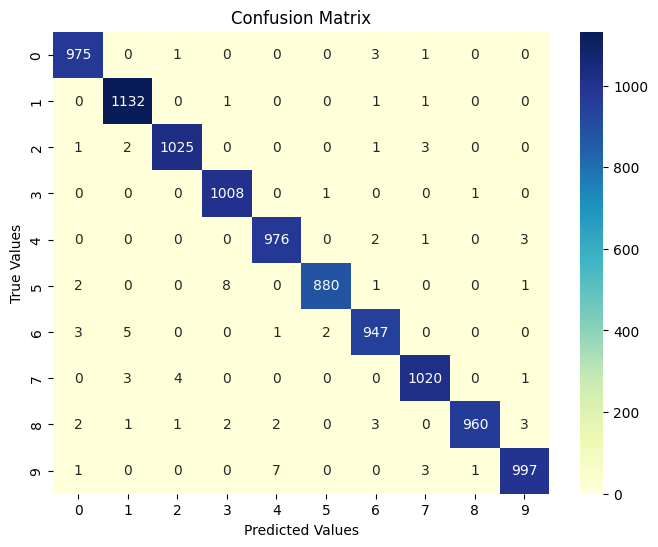

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'YlGnBu')
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("Confusion Matrix")
plt.show()

# **Missclassified Digit Analysis**

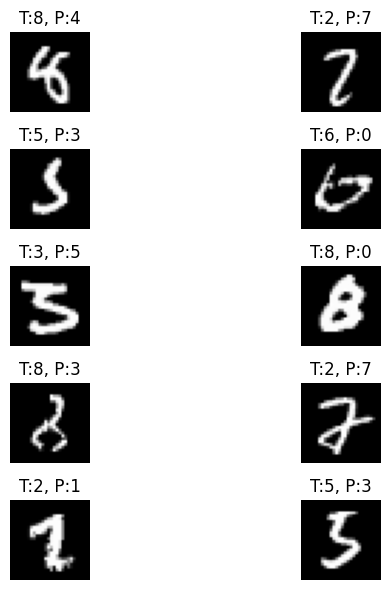

In [32]:
misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize = (8, 6))
for i, idx in enumerate(misclassified[:10]):
  plt.subplot(5, 2, i + 1)
  plt.imshow(X_test[idx].squeeze(), cmap = 'gray')
  plt.title(f"T:{y_test[idx]}, P:{y_pred[idx]}")
  plt.axis("off")
plt.tight_layout()
plt.show()
# tracks both the loop count (i from 0 to 9) and the actual dataset index (idx).

# **Save Model**

In [33]:
model.save('digit_classifier.keras')

In [34]:
import json
with open("training_hist.json", 'w') as f:
  json.dump(history.history, f)